# Analisi di sopravvivenza del tempo all'abbandono in una coorte di studenti

## Sintesi esecutiva

**Contesto.** Un ufficio di ricerca istituzionale di un college quadriennale vuole capire *quando*, e non solo *se*, gli studenti abbandonano. Una coorte di studenti alla prima iscrizione viene seguita periodo per periodo dalla matricolazione; alcuni si laureano, alcuni abbandonano e alcuni sono ancora iscritti quando la finestra di osservazione si chiude. Poiché l'esito degli studenti ancora iscritti è ignoto (censurato a destra), e poiché la laurea rimuove uno studente dal pool a rischio senza essere un abbandono, una comune regressione superato/non superato scarta l'informazione temporale e distorce qualsiasi stima che ignori la censura. Lo strumento corretto è l'**analisi del tempo all'evento (analisi di sopravvivenza)**, dove l'evento di interesse è l'**abbandono** e il tempo si misura in periodi accademici di iscrizione.

**Domanda di business.** La **posizione accademica del primo periodo** di uno studente (un segnale di allerta precoce) separa le traiettorie temporali dell'abbandono della coorte, e quali caratteristiche dello studente determinano il rischio (hazard) di abbandono dopo l'aggiustamento? Le risposte alimentano un sistema di allerta precoce: gli studenti il cui rischio stimato di abbandono è elevato dovrebbero ricevere un intervento di tutoraggio nei loro primi periodi, quando l'intervento è più economico e più efficace.

**Approccio.** Simuliamo una coorte di 100 studenti inline (senza dati esterni), poi seguiamo un flusso di lavoro standard di analisi di sopravvivenza:

1. **PROC MEANS** profila i predittori nei tre esiti osservati (Laureati / Abbandonati / ancora Iscritti) per confermare che il segnale simulato si comporti in modo sensato.
2. **PROC FREQ** effettua la tabulazione incrociata della posizione accademica del primo periodo con l'esito tramite un test chi-quadrato di associazione.
3. **PROC UNIVARIATE** riporta percentili robusti del tempo all'abbandono per posizione.
4. **PROC LIFETEST** stima le curve di abbandono di Kaplan-Meier stratificate per posizione ed esegue i test di uguaglianza **log-rank** e **Wilcoxon**.
5. **PROC PHREG** adatta un modello multivariabile a **rischi proporzionali di Cox** per il rischio di abbandono, con un effetto `CLASS` codificato per riferimento, gestione dei ties di Efron e intervalli di confidenza sui limiti di rischio.

**Cosa mostrano i dati.** Dei 100 studenti simulati, **49 hanno abbandonato, 49 si sono laureati e 2 sono rimasti iscritti** al limite dei 12 periodi. Gli studenti segnalati per **allerta accademica** nel loro primo periodo (GPA del primo periodo inferiore a 2,5) abbandonano molto più rapidamente degli studenti in buona posizione: tempo mediano all'abbandono **3,8 periodi contro 8,7 periodi**, una separazione che il test log-rank conferma (chi-quadrato = 10,73, *p* = 0,0011). Il modello di Cox identifica il GPA del primo periodo (rapporto di rischio 0,21 per punto di GPA, *p* < 0,0001), il GPA della scuola superiore (HR 0,45, *p* = 0,027) e lo status di prima generazione (HR 2,03, *p* = 0,031) come fattori aggiustati significativi dell'abbandono, mentre lo status di borsa Pell non è significativo una volta controllato il GPA (HR 0,95, *p* = 0,85).

> *Tutte le cifre sono illustrative e generate da dati sintetici; non sono veri dati di studenti. Questo ambiente funziona senza licenza, quindi la coorte è dimensionata a 100 studenti.*

## Fonti dei dati

Tutti i dati sono **sintetici**, generati inline nel primo DATA step con `CALL STREAMINIT(20260611)` e la funzione `RAND`. Nessun file esterno o accesso di rete. Una riga per ogni studente simulato.

**Dataset `iscrizioni`** (100 righe, una riga per studente)

| Variabile | Tipo | Descrizione | Distribuzione generatrice |
|----------|------|-------------|--------------------------|
| `id_studente` | Num | Chiave univoca dello studente | sequenza 1–100 |
| `prima_gen` / `prima_gen_lbl` | Num / Char | Flag di prima generazione (0/1) ed etichetta | Bernoulli, ~42% |
| `pell` | Num | Flag borsa Pell (necessità finanziaria) (0/1) | Bernoulli, ~42% |
| `programma` | Char | STEM / BUS / HUM | categorica (~42% / 32% / 26%) |
| `gpa_superiori` | Num | GPA della scuola superiore (1,8–4,0) | Normale(3,00, 0,42), limitata |
| `gpa_primo_periodo` | Num | GPA universitario del primo periodo (0–4,0) | f(gpa_superiori, programma) + rumore Normale |
| `posizione` | Char | Posizione accademica del primo periodo | `gpa_primo_periodo < 2.5` → Allerta accademica, altrimenti Buona posizione |
| `tempo_periodi` | Num | Periodi di iscrizione fino all'evento o alla censura | estrazioni Weibull in competizione; limitato a 12 |
| `abbandonato` | Num | Indicatore dell'evento di abbandono (1 = abbandonato, 0 = censurato) | derivato |
| `esito` | Char | Laureato / Abbandonato / Iscritto | derivato dalle estrazioni in competizione |

Un predittore lineare latente sulla scala logaritmica collega il **tasso di abbandono** di ciascuno studente al GPA del primo periodo, al GPA della scuola superiore, allo status di prima generazione e alla necessità finanziaria, così che i predittori portino un segnale genuino ma rumoroso. L'abbandono e la laurea sono estratti come tempi latenti **in competizione** (Weibull); quello che si verifica per primo all'interno di una finestra di 12 periodi diventa l'esito osservato, e gli studenti che raggiungono il periodo 12 senza nessuno dei due sono censurati a destra. Per i modelli di sopravvivenza l'**evento è l'abbandono** (`abbandonato = 1`); la laurea e l'iscrizione in corso sono entrambe trattate come censura (`abbandonato = 0`).

## 1. Simulare la coorte di studenti

La prima cella costruisce una coorte sintetica di 100 studenti. Un predittore lineare latente sulla scala logaritmica lega il tasso di abbandono di ciascuno studente al GPA del primo periodo, al GPA della scuola superiore, allo status di prima generazione e allo status Pell. L'abbandono e la laurea sono generati come tempi latenti **in competizione** (estrazioni Weibull); quello che accade per primo all'interno di una finestra di osservazione di 12 periodi diventa l'esito osservato, e gli studenti che raggiungono il periodo 12 senza abbandonare o laurearsi sono censurati a destra. Un GPA del primo periodo inferiore a 2,5 segnala lo studente per **allerta accademica** — il segnale di allerta precoce che testiamo nel passo di sopravvivenza. Le estrazioni casuali usano `CALL STREAMINIT` per la riproducibilità e la funzione `RAND` per le distribuzioni Uniforme, Normale e Weibull. Limiti inferiori e vincoli rigidi mantengono ogni valore plausibile (GPA in 0–4,0).

In [1]:
DATI iscrizioni;
    CHIAMARE streaminit(20260611);
    LUNGHEZZA posizione $24 prima_gen_lbl $24 programma $4 esito $12;

    ETICHETTA id_studente       = "Chiave studente"
          prima_gen         = "Flag prima generazione (0/1)"
          prima_gen_lbl     = "Status prima generazione"
          pell              = "Flag borsa Pell (0/1)"
          programma         = "Programma di studio"
          gpa_superiori     = "GPA scuola superiore"
          gpa_primo_periodo = "GPA primo periodo"
          posizione         = "Posizione accademica primo periodo"
          tempo_periodi     = "Periodi fino a evento/censura"
          abbandonato       = "Indicatore abbandono (1=si)"
          esito             = "Esito osservato";

    FARE id_studente = 1 FINO_A 100;
        /* Flag prima generazione e necessita' finanziaria */
        prima_gen = (rand("uniform") < 0.42);
        SE_COND prima_gen ALLORA prima_gen_lbl = "Prima generazione";
        ALTRIMENTI               prima_gen_lbl = "Generazione continua";
        pell = (rand("uniform") < 0.42);

        /* Programma di studio */
        v = rand("uniform");
        SE_COND      v < 0.42 ALLORA programma = "STEM";
        ALTRIMENTI SE_COND v < 0.74 ALLORA programma = "BUS";
        ALTRIMENTI                  programma = "HUM";

        /* Preparazione accademica e rendimento del primo periodo */
        gpa_superiori = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        gpa_primo_periodo = round(MIN(4.0, MAX(0.0,
                     0.55*gpa_superiori + 1.05 + 0.12*(programma="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Allerta precoce: GPA primo periodo sotto 2.5 = allerta accademica */
        SE_COND gpa_primo_periodo < 2.5 ALLORA posizione = "Allerta accademica";
        ALTRIMENTI                            posizione = "Buona posizione";

        /* Rischio latente di abbandono su scala log: GPA piu' basso,
           prima generazione e status Pell alzano il tasso di abbandono. */
        eta = -1.05
             - 1.45*(gpa_primo_periodo - 2.8)
             - 0.55*(gpa_superiori - 3.0)
             + 1.05*prima_gen
             + 0.45*pell;
        tasso_abbandono = EXP(eta);

        /* Tempi latenti in competizione (periodi): abbandono vs laurea */
        t_abbandono = rand("weibull", 1.2, 7.0) / MAX(0.30, tasso_abbandono);
        t_laurea = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(gpa_primo_periodo - 2.8));

        /* Finestra di censura amministrativa di 12 periodi */
        censura_periodo = 12;
        SE_COND t_abbandono <= t_laurea E_LOG t_abbandono <= censura_periodo ALLORA FARE;
            esito = "Abbandonato"; abbandonato = 1; tempo_periodi = t_abbandono;
        FINE;
        ALTRIMENTI SE_COND t_laurea < t_abbandono E_LOG t_laurea <= censura_periodo ALLORA FARE;
            esito = "Laureato"; abbandonato = 0; tempo_periodi = t_laurea;
        FINE;
        ALTRIMENTI FARE;
            esito = "Iscritto"; abbandonato = 0; tempo_periodi = censura_periodo;
        FINE;
        tempo_periodi = round(tempo_periodi, 0.1);
        USCITA;
    FINE;
    MANTENERE id_studente prima_gen prima_gen_lbl pell programma gpa_superiori
         gpa_primo_periodo posizione tempo_periodi abbandonato esito;
ESEGUIRE;


NOTE: DATA iscrizioni


NOTE: Wrote iscrizioni (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profilare i predittori per esito osservato

Prima di modellare, confermiamo che i predittori simulati si muovano nelle direzioni attese. **PROC MEANS** riporta il conteggio, la media, la dispersione e l'intervallo di ciascun predittore numerico all'interno dei tre esiti osservati.

La coorte si divide in **49 Laureati / 49 Abbandonati / 2 ancora Iscritti**. I laureati portano un GPA del primo periodo più alto (media **2,94** contro **2,54** per gli studenti che hanno abbandonato) e un GPA della scuola superiore più alto (**3,10** contro **2,90**) — esattamente il gradiente di preparazione accademica che l'analisi si aspetta. I due studenti ancora iscritti si collocano esattamente al tetto di censura dei 12 periodi su `tempo_periodi` (media 12,00, deviazione standard 0), la censura a destra che un'analisi dell'abbandono deve rispettare. Tra gli studenti che hanno abbandonato, l'evento arriva presto: media **3,31 periodi**, con un intervallo da 0,1 a 8,9.

In [2]:
PROCEDURA MEDIE DATI=iscrizioni n mean std MIN MAX maxdec=2;
    CLASSE esito;
    VARIABILE gpa_superiori gpa_primo_periodo tempo_periodi;
ESEGUIRE;

                                                  The MEANS Procedure

                                 Analysis Variable : gpa_superiori GPA scuola superiore

        Esito osservato          N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        Abbandonato                 49           2.90           0.45           2.01           3.89
        Iscritto                     2           3.10           0.17           2.98           3.22
        Laureato                    49           3.10           0.46           1.97           4.00
        ------------------------------------------------------------------------------------------

                                Analysis Variable : gpa_primo_periodo GPA primo periodo

        Esito osservato          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Il segnale di allerta precoce traccia l'esito?

Il sistema di allerta precoce segnala per **allerta accademica** ogni studente il cui GPA del primo periodo scenda sotto 2,5. **PROC FREQ** effettua la tabulazione incrociata di quel segnale rispetto all'esito osservato ed esegue un test chi-quadrato di associazione. Sopprimiamo le percentuali di riga, colonna e complessive (`NOROW NOCOL NOPERCENT`) così che la tabella mostri i conteggi grezzi, e aggiungiamo frequenze univariate di `posizione` e dello status di prima generazione per la composizione della coorte.

La tabulazione incrociata è netta: dei **29** studenti segnalati per allerta accademica, **21 hanno abbandonato** e solo 8 si sono laureati; dei **71** in buona posizione, **41 si sono laureati** e 28 hanno abbandonato. L'associazione è significativa (chi-quadrato = 9,21, gl = 2, *p* = 0,0100; V di Cramer = 0,30). Si noti l'**avvertimento stampato insieme**: con 100 studenti e una colonna "Iscritti" sottile di soli due laureati, un terzo delle celle della tabella ha conteggi attesi inferiori a 5, quindi il valore *p* del chi-quadrato è fragile qui. Quella fragilità è esattamente il motivo per cui i test di sopravvivenza nelle sezioni successive — che usano l'informazione temporale completa anziché una tabella 3×2 — sono il test più affidabile dell'effetto della posizione.

                                                   The FREQ Procedure

Table of Posizione accademica primo periodo by Esito osservato

Posizione accademica primo periodo |Abbandonato |   Iscritto |   Laureato |       Total
-----------------------------------+------------+------------+------------+------------
Allerta accademica                 |         21 |          0 |          8 |          29
-----------------------------------+------------+------------+------------+------------
Buona posizione                    |         28 |          2 |         41 |          71
-----------------------------------+------------+------------+------------+------------
Total                              |         49 |          2 |         49 |         100

Statistics for Table of Posizione accademica primo periodo by Esito osservato

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_posizione_esito.spec.json
NOTE: ODS plot written: freq_posizione.spec.json
NOTE: ODS plot written: freq_prima_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


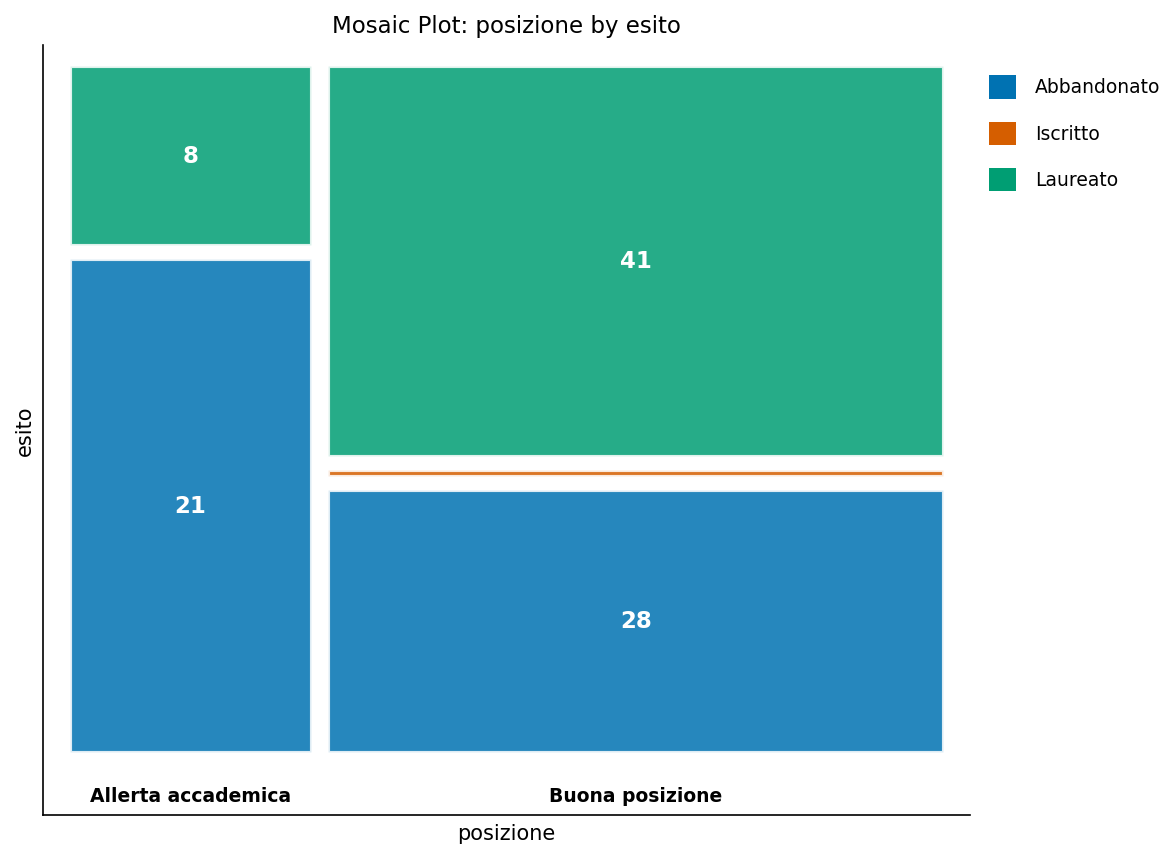

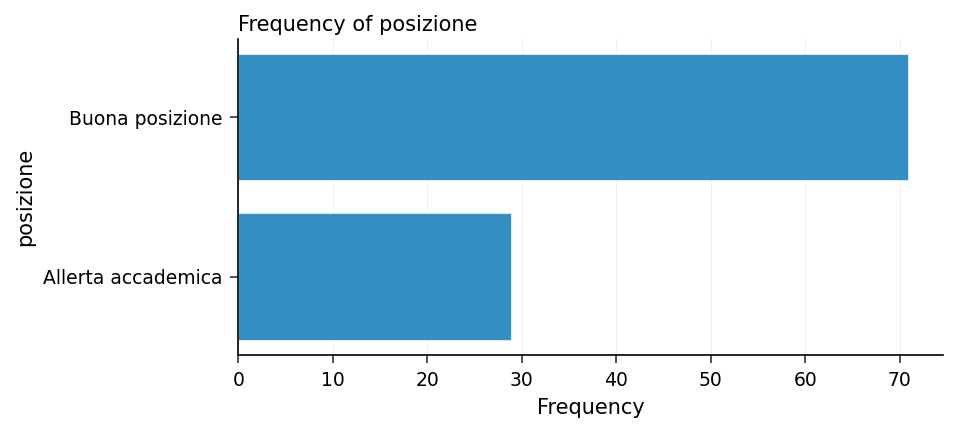

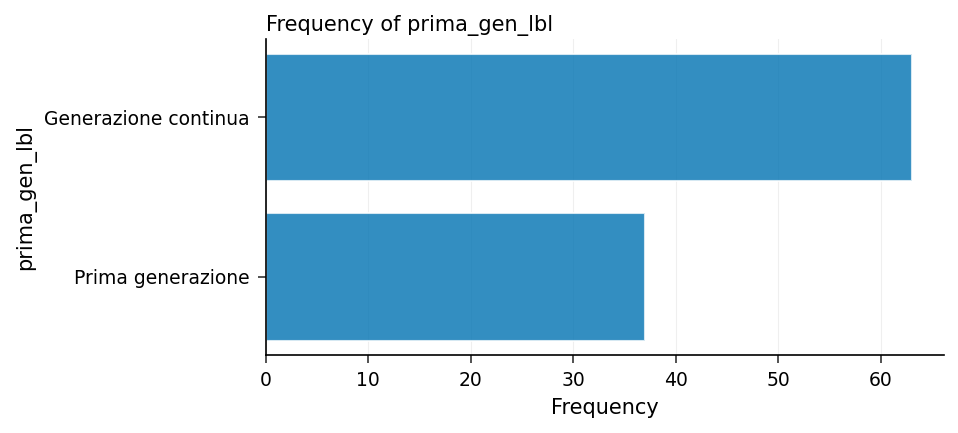

In [3]:
PROCEDURA FREQUENZE DATI=iscrizioni;
    TABLES posizione*esito / chisq norow nocol nopercent;
    TABLES posizione prima_gen_lbl;
ESEGUIRE;

## 4. Quando avvengono gli abbandoni? Percentili per posizione

Per gli studenti che hanno effettivamente abbandonato, *quando* se ne sono andati? **PROC UNIVARIATE** (limitato a `abbandonato = 1`) riporta il 10°, il 50° (mediana) e il 90° percentile del tempo all'abbandono all'interno di ciascun gruppo di posizione, scritti in un dataset di output che poi stampiamo. Questo descrive la dispersione dei tempi di abbandono senza assumere una distribuzione.

L'abbandono mediano tra gli studenti che se ne sono andati si verifica intorno al periodo **2,4** (allerta accademica) contro **2,6** (buona posizione) — vicini, perché *a condizione di abbandonare*, entrambi i gruppi tendono ad andarsene presto. L'effetto della posizione non riguarda quindi principalmente *quando* avviene un abbandono ma *quanti* studenti abbandonano e quanto velocemente si assottiglia il pool a rischio, che è precisamente ciò che catturano le curve di Kaplan-Meier nella sezione successiva.

In [4]:
PROCEDURA UNIVARIATE DATI=iscrizioni NOPRINT;
    DOVE abbandonato = 1;
    CLASSE posizione;
    VARIABILE tempo_periodi;
    USCITA out=rif_abbandono pctlpts=10 50 90 pctlpre=t_ p=;
ESEGUIRE;

PROCEDURA STAMPARE DATI=rif_abbandono noobs ETICHETTA;
    TITOLO "Percentili del tempo all'abbandono (periodi), per posizione accademica";
ESEGUIRE;
TITOLO;

                         Percentili del tempo all'abbandono (periodi), per posizione accademica                         

         POSIZIONE  T_10  T_50  T_90
Allerta accademica   0.2   2.4   7.9
Buona posizione      0.4   2.6   8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset rif_abbandono has 2 observations and 4 variables.
NOTE: PROC PRINT data=rif_abbandono

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Curve di abbandono di Kaplan-Meier per posizione accademica

Ora il passo centrale della sopravvivenza. **PROC LIFETEST** stima la funzione di sopravvivenza nonparametrica di **Kaplan-Meier** per il *tempo all'abbandono*, trattando la laurea e l'iscrizione in corso come censura (`abbandonato(0)` marca le osservazioni censurate). La stratificazione per `posizione` produce una curva di abbandono per gruppo, e `TEST=(LOGRANK WILCOXON)` esegue due test complementari per verificare se quelle curve differiscono: il test **log-rank** pesa tutti i tempi degli eventi in modo uguale (sensibile alle differenze tardive), mentre il test **Wilcoxon** dà maggior peso ai tempi degli eventi precoci (sensibile all'abbandono precoce). `PLOTS=SURVIVAL` richiede il grafico sovrapposto delle curve di sopravvivenza.

Nell'intera coorte ci sono **49 eventi di abbandono e 51 osservazioni** censurate. Le curve si separano chiaramente: gli studenti in allerta accademica raggiungono una **sopravvivenza mediana (tempo all'abbandono) di 3,8 periodi**, mentre gli studenti in buona posizione durano più del doppio (**8,7 periodi**). Entrambi i test rifiutano l'uguaglianza — **chi-quadrato log-rank = 10,73, *p* = 0,0011; chi-quadrato Wilcoxon = 7,66, *p* = 0,0056** — e le statistiche confrontabili ci dicono che il divario è sostenuto attraverso l'intera finestra di iscrizione, non solo un picco iniziale. Il grafico rende il messaggio immediato: la curva arancione dell'allerta accademica scende ripidamente durante i primi quattro periodi, mentre la curva blu della buona posizione resta alta.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Posizione accademica primo periodo = Allerta accademica

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7


NOTE: PROC LIFETEST data=iscrizioni

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


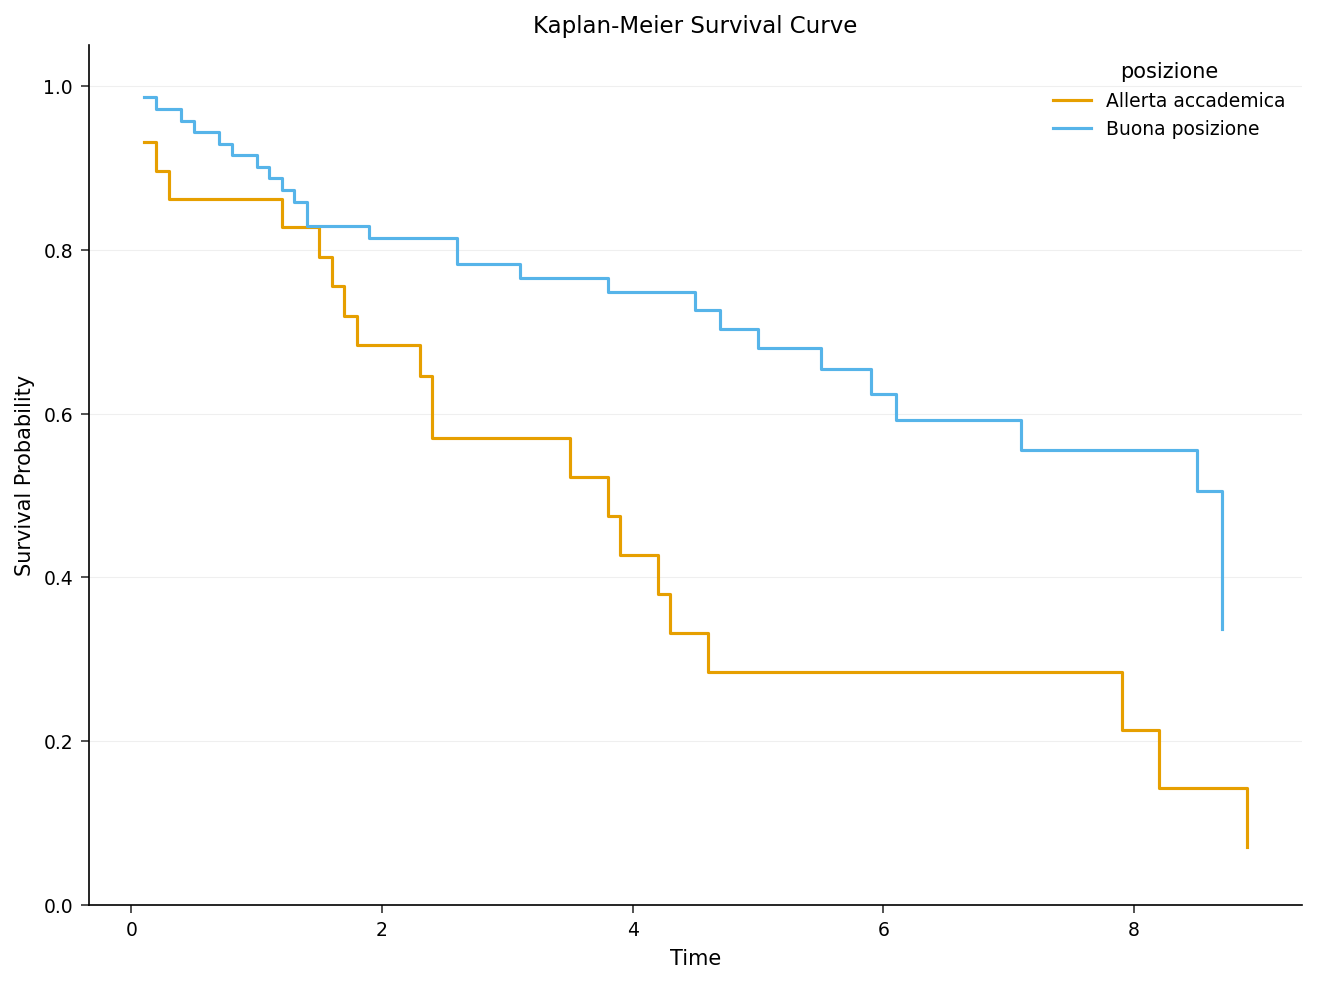

In [5]:
PROCEDURA LIFETEST DATI=iscrizioni PLOTS=SURVIVAL METHOD=km;
    TIME tempo_periodi*abbandonato(0);
    STRATA posizione / TEST=(logrank WILCOXON);
ESEGUIRE;

## 6. Modello multivariabile a rischi proporzionali di Cox per l'abbandono

**PROC PHREG** adatta il modello a **rischi proporzionali di Cox** per il rischio di abbandono, aggiustando i predittori simultaneamente. Richieste chiave:

- `abbandonato(0)` rende l'**abbandono** l'evento e tutto il resto censurato.
- `CLASS prima_gen_lbl (ref="Generazione continua") / param=ref` codifica per riferimento il fattore di prima generazione così che il suo rapporto di rischio si legga rispetto agli studenti di generazione continua.
- `TIES=EFRON` è l'approssimazione raccomandata per la gestione dei ties quando diversi studenti se ne vanno nello stesso periodo.
- `RL` aggiunge intervalli di confidenza sul rapporto di rischio (limiti di rischio).
- L'istruzione `HAZARDRATIO` riporta il contrasto di prima generazione rispetto al gruppo di riferimento.

Un rapporto di rischio superiore a 1 significa abbandono *più veloce* (rischio più alto); inferiore a 1 significa abbandono *più lento* (protettivo).

In [6]:
PROCEDURA PHREG DATI=iscrizioni;
    CLASSE prima_gen_lbl (REF="Generazione continua") / PARAM=REF;
    MODELLO tempo_periodi*abbandonato(0) = gpa_superiori gpa_primo_periodo prima_gen_lbl pell
          / TIES=efron rl;
    hazardratio "Prima generazione vs continua" prima_gen_lbl / DIFF=REF;
ESEGUIRE;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                              Analysis of Maximum Likelihood Estimates                                               

Parameter                              DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------


NOTE: PROC PHREG data=iscrizioni

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretazione e prossimi passi

**Lettura dell'output, dall'inizio alla fine:**

- **PROC MEANS** conferma il segnale simulato: gli studenti che si sono laureati portano un GPA del primo periodo più alto (2,94 contro 2,54) e un GPA della scuola superiore più alto (3,10 contro 2,90) rispetto agli studenti che hanno abbandonato, e gli studenti ancora iscritti si collocano al tetto dei 12 periodi — la censura a destra che i modelli di sopravvivenza rispettano.
- **PROC FREQ** mostra che il segnale di allerta accademica del primo periodo traccia l'esito (21 dei 29 studenti segnalati hanno abbandonato; 41 dei 71 studenti in buona posizione si sono laureati; *p* = 0,0100), pur segnalando onestamente che il chi-quadrato è fragile in una tabella di 100 studenti con celle rade.
- **PROC UNIVARIATE** mostra che *a condizione di abbandonare*, entrambi i gruppi se ne vanno presto (mediana ~2,4–2,6 periodi); l'effetto della posizione riguarda quanti studenti abbandonano e quanto velocemente si assottiglia il pool a rischio, non il momento tra coloro che se ne vanno.
- **PROC LIFETEST** fornisce il risultato principale: le curve di abbandono di Kaplan-Meier che si separano nettamente per posizione (mediana 3,8 contro 8,7 periodi; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). Il segnale di allerta precoce è un discriminatore genuino e statisticamente supportato dei tempi di abbandono.
- **PROC PHREG** quantifica l'effetto aggiustato di ciascun predittore sul rischio di abbandono. Dopo l'aggiustamento, **il GPA del primo periodo è il fattore protettivo più forte** (rapporto di rischio 0,21 per punto di GPA, IC 95% 0,10–0,44, *p* < 0,0001): ogni punto di GPA aggiuntivo riduce il rischio di abbandono di circa quattro quinti. Anche il **GPA della scuola superiore** è protettivo (HR 0,45, IC 95% 0,22–0,91, *p* = 0,027). Gli **studenti di prima generazione** affrontano circa il doppio del rischio di abbandono rispetto ai coetanei di generazione continua con gli stessi GPA (HR 2,03, IC 95% 1,07–3,84, *p* = 0,031). Lo **status Pell non è significativo** una volta controllato il GPA (HR 0,95, IC 95% 0,53–1,69, *p* = 0,85) — un utile promemoria che un fattore di rischio grezzo può svanire dopo l'aggiustamento. L'ipotesi nulla globale è decisamente rifiutata (chi-quadrato del rapporto di verosimiglianza = 31,11 su 4 gl, *p* < 0,0001).

**Come un'istituzione agirebbe su questo.** Il modello di Cox produce un predittore lineare per studente (punteggio di rischio) che ordina la coorte per rischio di abbandono; gli studenti a rischio più elevato — basso GPA del primo periodo combinato con lo status di prima generazione — vengono indirizzati al tutoraggio di allerta precoce nei loro primi periodi, quando l'intervento è più economico e più efficace. Il confronto di Kaplan-Meier fornisce ai tutor un unico criterio difendibile che già raccolgono alla fine del primo periodo: la posizione accademica.

**Avvertenze ed estensioni.** (1) Questa coorte sintetica tratta la laurea come censura per il modello di abbandono; con dati reali, laurea e abbandono sono genuini **rischi in competizione**, e un'estensione a rischi in competizione (incidenza cumulativa) tramite `EVENTCODE=` di PROC PHREG eviterebbe di sovrastimare la probabilità di abbandono. (2) L'assunzione dei rischi proporzionali dovrebbe essere verificata (`ASSESS PH` di PHREG o residui di Schoenfeld) prima di fidarsi di un singolo rapporto di rischio attraverso tutti i periodi. (3) Le covariate tempo-varianti — GPA periodo per periodo, cambiamenti negli aiuti finanziari, carico di corsi — sono comuni nei dati di ritenzione e sono gestite naturalmente dalle istruzioni di programmazione di PHREG. (4) La coorte di 100 studenti qui è dimensionata al limite di esecuzione senza licenza; un'analisi di produzione porterebbe diverse migliaia di studenti, restringendo ogni intervallo di confidenza. Convalidare sempre un punteggio di rischio distribuito su una coorte tenuta da parte prima di agirvi operativamente.